<a href="https://colab.research.google.com/github/rupeshjajedy-jpg/my-work/blob/main/assignment_by_Rupesh_kumar_(2520010466).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Problem Understanding:
The objective of this project is to predict whether a patient is suffering from heart disease based on medical attributes.
Since the target variable is binary (0 = No disease, 1 = Disease), Logistic Regression is an appropriate choice.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('/content/heart.csv')
df.head()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Data Loading & Basic Checks
The dataset was loaded using pandas. Initial inspection using head(), info(), and describe() helped understand:
- Number of rows and columns
- Data types of variables
- Absence of missing values
Since no null values were found, no data imputation was required.


In [ ]:
df.shape

(303, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
#Checking missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


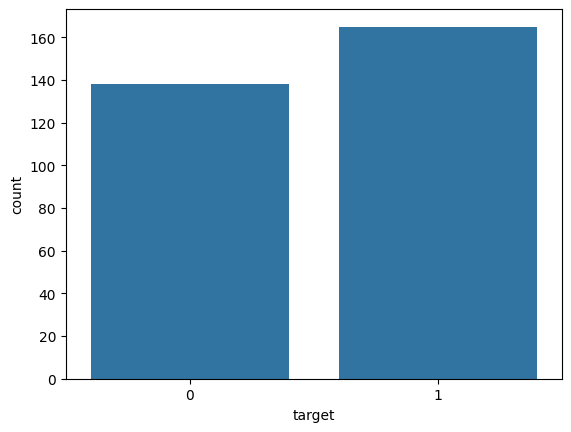

In [ ]:
#Target Variable Distribution (EDA)
sns.countplot(x='target', data=df)
plt.show()

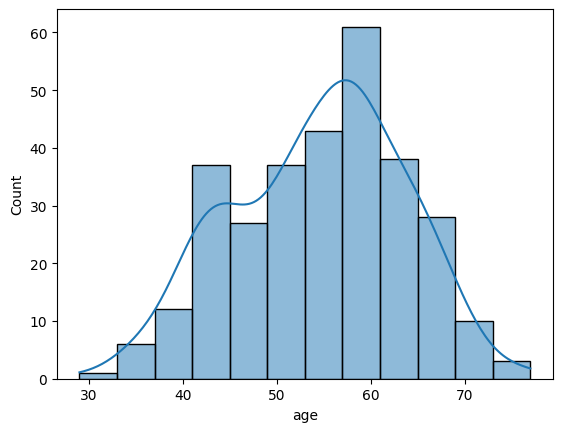

In [ ]:
#Univariate Analysis (EDA)

#1)Age Distribution
sns.histplot(df['age'], kde=True)
plt.show()


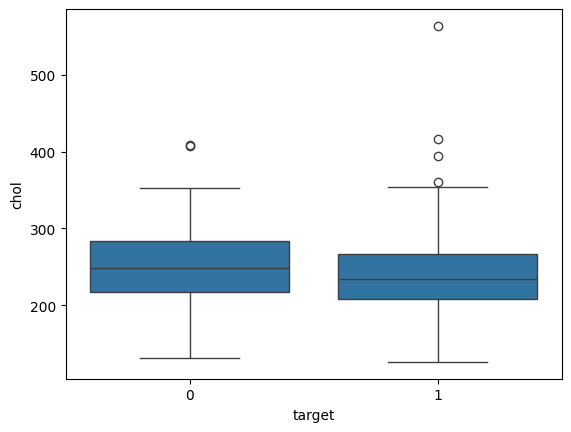

In [ ]:
#2)Cholesterol vs Target
sns.boxplot(x='target', y='chol', data=df)
plt.show()


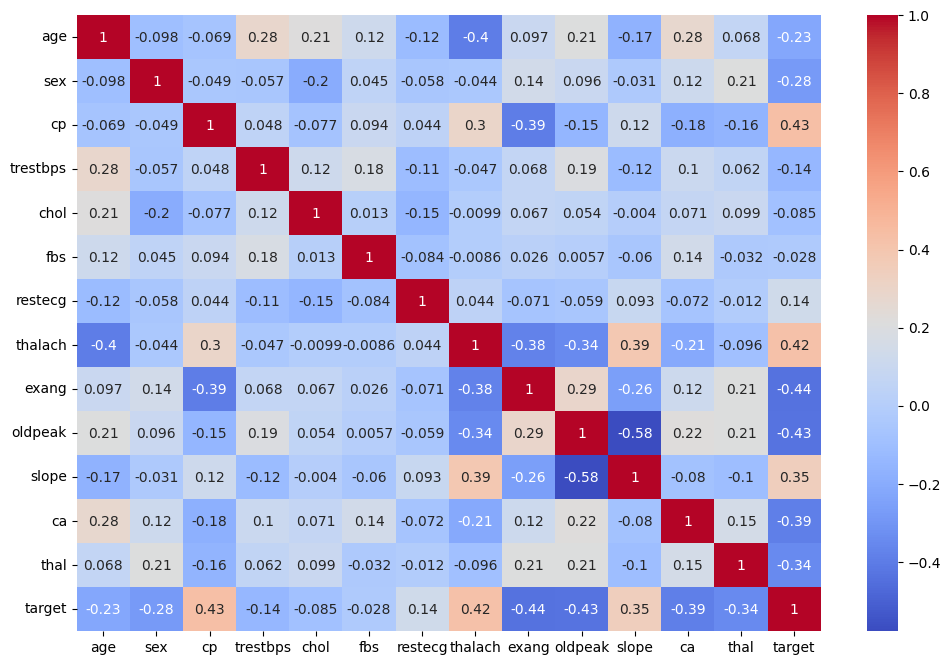

In [ ]:
#Correlation Analysis
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Exploratory Data Analysis (EDA)
EDA was performed to understand data distribution and relationships.
- Target variable distribution showed that classes are fairly balanced.
- Age distribution indicated that middle-aged individuals are more prone to heart disease.
- Boxplots revealed that higher cholesterol levels are associated with heart disease.
- Correlation heatmap highlighted important features like chest pain type (cp), maximum heart rate (thalach), and oldpeak


In [ ]:
#Feature – Target Split
X = df.drop('target', axis=1)
y = df['target']

Feature & Target Separation
Independent variables (X) were separated from the dependent variable (y).
This step is necessary to train the machine learning model.



Train-Test Split
The dataset was split into training (80%) and testing (20%) sets.
This ensures that model performance is evaluated on unseen data.


In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling:
StandardScaler was used to normalize the features.
Scaling is essential for Logistic Regression because it is distance-based and sensitive to feature magnitude.


In [ ]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Training:
Logistic Regression model was trained using scaled training data.
The model learned relationships between features and the probability of heart disease.


In [ ]:
#Build Logistic Regression Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

Predictions were generated on the test dataset.
Additionally, predict_proba() was used to obtain probabilities for ROC-AUC analysis.


In [ ]:
#Prediction
y_pred = model.predict(X_test_scaled)

In [ ]:
#Model Evaluation
#Accuracy
accuracy_score(y_test, y_pred)


0.8524590163934426

Accuracy Score measured overall correctness of predictions.
- Confusion Matrix showed True Positives, True Negatives, False Positives, and False Negatives.
- Classification Report provided Precision, Recall, and F1-score for deeper evaluation.


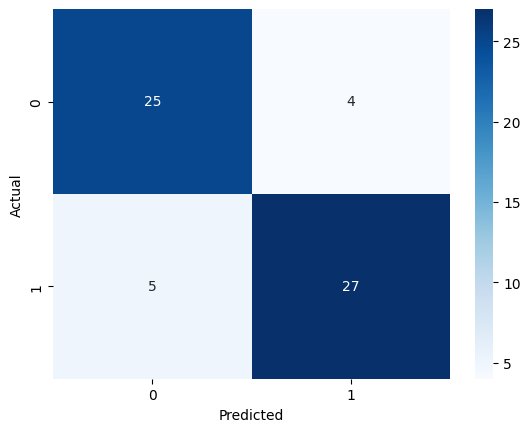

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
#Classification Report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



Model Interpretation:
Logistic Regression coefficients explained the impact of each feature.
Positive coefficients increased the likelihood of heart disease, while negative coefficients reduced it.


In [ ]:
#Model Interpretation
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,cp,0.817904
10,slope,0.435302
7,thalach,0.395131
6,restecg,0.284179
5,fbs,0.090312
0,age,-0.085591
4,chol,-0.174841
3,trestbps,-0.273307
8,exang,-0.517584
12,thal,-0.565659


ROC curve plotted True Positive Rate against False Positive Rate at various thresholds.
The AUC score quantified the model’s ability to distinguish between diseased and non-diseased patients.
An AUC value close to 1 indicates excellent performance.


In [ ]:
#ROC curve
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#Importing ROC tools
from sklearn.metrics import roc_curve, roc_auc_score


In [ ]:
#Calculating FPR, TPR
fpr, tpr, thresholds = roc_curve(y_test, y_prob)


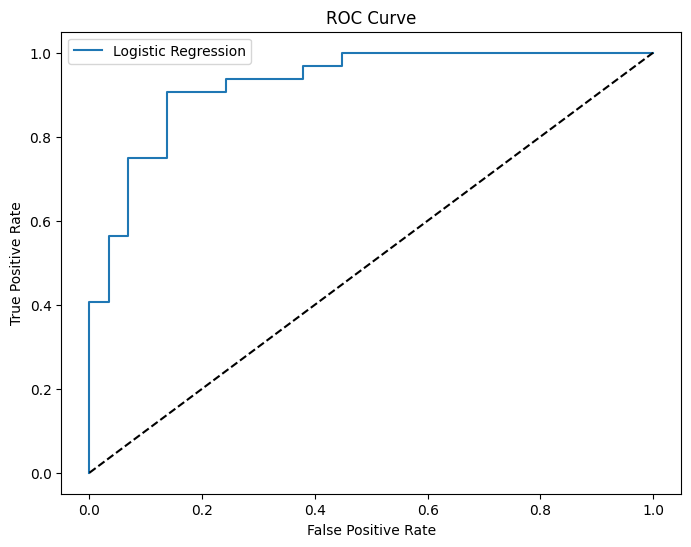

In [ ]:
#Ploting ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--')   # random model line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


ROC curve plotted True Positive Rate against False Positive Rate at various thresholds.
The AUC score quantified the model’s ability to distinguish between diseased and non-diseased patients.
An AUC value close to 1 indicates excellent performance.


In [ ]:
#AUC Score
auc_score = roc_auc_score(y_test, y_prob)
auc_score


np.float64(0.9267241379310345)

The Logistic Regression model performed well with good accuracy and high AUC score.
Proper EDA, feature scaling, and evaluation ensured a robust and interpretable model suitable for medical classification problems.
